# Genetic Algorithm
Note: <br>
For this algorithm to run the clients, employees and their nearest_segments have to be calculated in advance.

Genetic representation: <br>
List of clients in order of being calculated.

Mutation: <br>
Swap mutation to change the path randomly. Each mutation will use one parent to make sure no duplicate clients get added.

Tournament selection: <br>
Used to get a fair spread of good and bad states.

Elitism survivor selection: <br>
To make sure we do not go back in progress.

In [1]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import osmnx as ox
import numpy as np
from shapely import wkt

# Importing and cleaning

In [2]:
# Load data
clients_df = pd.read_csv("../output/clients.csv")
employees_df = pd.read_csv("../output/employees.csv")
clients_nearest_segments = pd.read_csv("../output/client_nearest_segments.csv")
employees_nearest_segments = pd.read_csv("../output/employee_nearest_segments.csv")
heerlen_edge_table = pd.read_csv("../output/heerlen_edge_table.csv")

In [3]:
# Combine clients
clients_nearest_segments = clients_nearest_segments.rename(columns={"client_name": "name"})
clients_df = clients_df.merge(clients_nearest_segments, on="name", how="left")

# Keep the base client columns and remove duplicate right-side columns from merge.
clients_df = clients_df.drop(columns=["address_y", "coordinates_y"], errors="ignore")
clients_df = clients_df.rename(
    columns={
        "address_x": "address",
        "coordinates_x": "coordinates",
    }
)

# Parse coordinates in "lat lon" format into numeric columns used by downstream cells.
if "coordinates" in clients_df.columns:
    coord_parts = clients_df["coordinates"].astype(str).str.strip().str.split(r"\s+", n=1, expand=True)
    if coord_parts.shape[1] == 2:
        clients_df["lat"] = pd.to_numeric(coord_parts[0], errors="coerce")
        clients_df["lon"] = pd.to_numeric(coord_parts[1], errors="coerce")

clients_df.head(3)

,name,address,coordinates,care_arrangement,preferences,time_window_start,time_window_end,care_hours,dogs,cats,smokes,edge_id,u,v,key,edge_name,highway,distance_m,lat,lon
0,Client 1,"Putgraaf 478, 6411KN Heerlen",50.8870305 5.9850058,HBH Basic,morning,08:00,12:00,3.0,1,0,False,2164,42033003,42032089,0,Groene Boord,tertiary,30.806634,50.887031,5.985006
1,Client 2,"Tulpstraat 63-GB04, Heerlen",50.9235901 5.9630637,HBH Plus,afternoon,12:00,18:00,2.5,0,0,False,5109,42071791,42071604,0,Asterstraat | Tulpstraat,residential,30.541292,50.923590,5.963064
2,Client 2,"Tulpstraat 63-GB04, Heerlen",50.9235901 5.9630637,HBH Plus,afternoon,12:00,18:00,2.5,0,0,False,5093,42071604,42071791,0,Asterstraat | Tulpstraat,residential,30.541292,50.923590,5.963064


In [4]:
# Combine employees
employees_nearest_segments = employees_nearest_segments.rename(columns={'employee_name': 'name'})
employees_df = employees_df.merge(employees_nearest_segments, on="name", how="left")

# Keep the base employee columns and remove duplicate right-side columns from merge.
employees_df = employees_df.drop(columns=["address_y", "coordinates_y"], errors="ignore")
employees_df = employees_df.rename(
    columns={
        "address_x": "address",
        "coordinates_x": "coordinates",
    }
)

# Parse coordinates in "lat lon" format into numeric columns used by downstream cells.
if "coordinates" in employees_df.columns:
    coord_parts = employees_df["coordinates"].astype(str).str.strip().str.split(r"\s+", n=1, expand=True)
    if coord_parts.shape[1] == 2:
        employees_df["lat"] = pd.to_numeric(coord_parts[0], errors="coerce")
        employees_df["lon"] = pd.to_numeric(coord_parts[1], errors="coerce")

employees_df.head(3)

,name,address,coordinates,time_window_start,time_window_end,dogs,cats,smokes,edge_id,u,v,key,edge_name,highway,distance_m,lat,lon
0,employee 1,"Dr. de Visserstraat 6, 6415HJ Heerlen",50.8979843 5.9881059,07:00,18:00,2,-1,True,3133,42045886,42044822,0,Doctor de Visserstraat,residential,8.102585,50.897984,5.988106
1,employee 1,"Dr. de Visserstraat 6, 6415HJ Heerlen",50.8979843 5.9881059,07:00,18:00,2,-1,True,2982,42044822,42045886,0,Doctor de Visserstraat,residential,8.102585,50.897984,5.988106
2,employee 2,"Geerstraat 258, 6411NW Heerlen",50.8884582 5.9736771,07:00,18:00,-1,1,False,5617,1505263383,42033188,0,Geerstraat,residential,14.356675,50.888458,5.973677


# Setup Genetic Algorithm

In [5]:
# Initialize all necessary parts of the genetic algorithm
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

POPULATION_SIZE = 100
EPOCHS = 500

MUTATION_RATE = 1.00
MUTATION_STRIDE = 2

TOURNAMENT_SIZE = 5
ELITE_SIZE = max(1, int(0.10 * POPULATION_SIZE))

MAX_EMPLOYEE_WORK_TIME_MIN = 8 * 60

print("GA initialized:")
print(f"  seed={RANDOM_SEED}, population={POPULATION_SIZE}, epochs={EPOCHS}")
print(f"  mutation_rate={MUTATION_RATE}, mutation_stride={MUTATION_STRIDE}")
print(f"  tournament={TOURNAMENT_SIZE}, elite_size={ELITE_SIZE}")

GA initialized:
  seed=42, population=100, epochs=500
  mutation_rate=1.0, mutation_stride=2
  tournament=5, elite_size=10


In [6]:
# ============= Initial Population =============
NUM_CLIENTS = 100
client_indices = list(range(NUM_CLIENTS))
initial_population = [np.random.permutation(client_indices).tolist() for _ in range(POPULATION_SIZE)]

print(f"Initialized population with {len(initial_population)} individuals.")
print(f"Each individual contains {len(initial_population[0])} client indices.")
print("First individual:")
print(initial_population[0])

Initialized population with 100 individuals.
Each individual contains 100 client indices.
First individual:
[83, 53, 70, 45, 44, 39, 22, 80, 10, 0, 18, 30, 73, 33, 90, 4, 76, 77, 12, 31, 55, 88, 26, 42, 69, 15, 40, 96, 9, 72, 11, 47, 85, 28, 93, 5, 66, 65, 35, 16, 49, 34, 7, 95, 27, 19, 81, 25, 62, 13, 24, 3, 17, 38, 8, 78, 6, 64, 36, 89, 56, 99, 54, 43, 50, 67, 46, 68, 61, 97, 79, 41, 58, 48, 98, 57, 75, 32, 94, 59, 63, 84, 37, 29, 1, 52, 21, 2, 23, 87, 91, 74, 86, 82, 20, 60, 71, 14, 92, 51]


In [7]:
# ============= Mutation Function =============
def swap_mutation(parent):
    """
    Swap mutation: takes a single parent (list of client indices),
    creates a mutant by swapping MUTATION_STRIDE random position pairs.
    
    Args:
        parent: list of client indices representing a route order
        
    Returns:
        mutant: mutated copy of parent with swapped positions
    """
    mutant = parent.copy()
    
    # Perform MUTATION_STRIDE swaps
    for _ in range(MUTATION_STRIDE):
        # Select two random distinct indices
        i, j = np.random.choice(len(mutant), size=2, replace=False)
        # Swap them
        mutant[i], mutant[j] = mutant[j], mutant[i]
    
    return mutant

In [8]:
# ============= Tournament Selection =============
def tournament_selection(population, fitness_scores):
    """
    Tournament selection: randomly sample TOURNAMENT_SIZE individuals
    and return the best one (lower fitness is better for minimization).
    
    Args:
        population: list of individuals (each individual is a list of client indices)
        fitness_scores: list of fitness values corresponding to each individual
        
    Returns:
        winner: selected individual from the tournament
        winner_fitness: fitness score of the selected individual
    """
    # Sample unique indices for the tournament
    tournament_size = min(TOURNAMENT_SIZE, len(population))
    candidate_indices = np.random.choice(len(population), size=tournament_size, replace=False)
    
    # Find index of the best candidate in the sampled set (lower fitness is better)
    best_local_idx = np.argmin([fitness_scores[i] for i in candidate_indices])
    winner_index = candidate_indices[best_local_idx]
    
    winner = population[winner_index]
    winner_fitness = fitness_scores[winner_index]
    
    return winner, winner_fitness

In [9]:
# ============= Elitism Selection =============
def elitism_selection(population, fitness_scores):
    """
    Elitism selection: preserve the top ELITE_SIZE individuals from the population
    based on their fitness scores (lower fitness is better for minimization).
    
    Args:
        population: list of individuals (each individual is a list of client indices)
        fitness_scores: list of fitness values corresponding to each individual
        
    Returns:
        elite_individuals: list of the ELITE_SIZE best individuals
        elite_fitness: list of fitness scores for the elite individuals
    """
    # Get indices sorted by fitness (ascending - lower is better)
    sorted_indices = np.argsort(fitness_scores)[:ELITE_SIZE]
    
    # Extract elite individuals and their fitness scores
    elite_individuals = [population[i] for i in sorted_indices]
    elite_fitness = [fitness_scores[i] for i in sorted_indices]
    
    return elite_individuals, elite_fitness

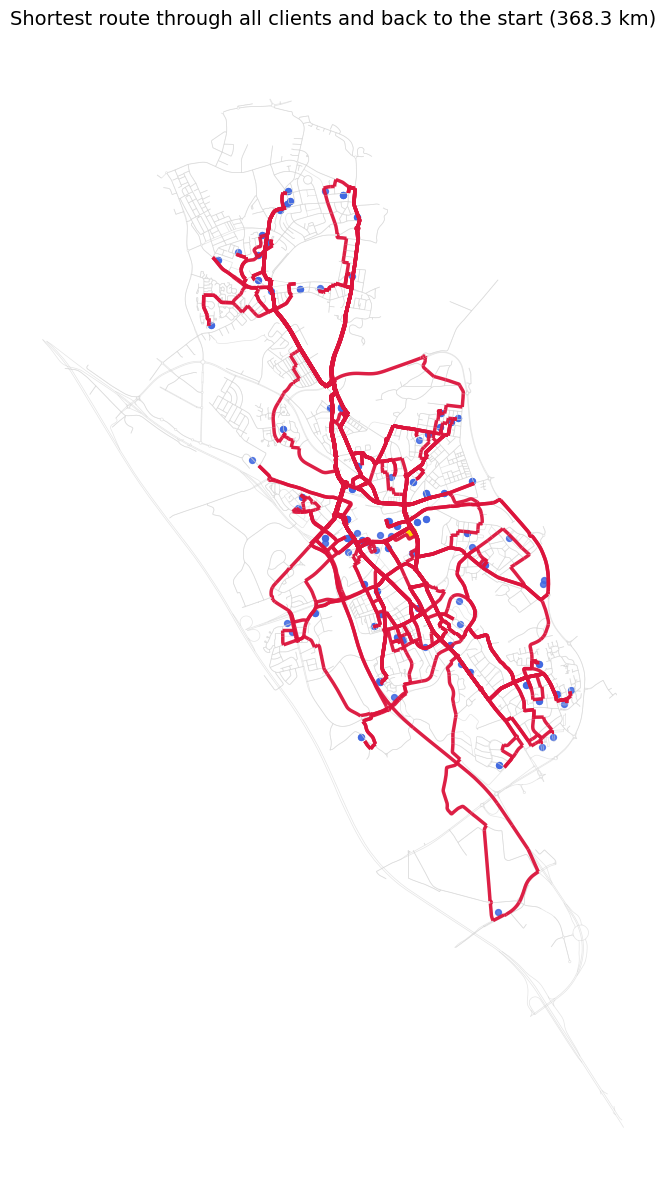

In [ ]:
# TEST: Go through every client in the current dataset and return to the start.
import networkx as nx
from itertools import pairwise
from shapely.geometry import LineString

# Build a road graph from the edge table that already has corrected geometry direction.
road_graph = nx.MultiDiGraph()
road_graph.graph["crs"] = "EPSG:4326"

# Ensure GeoDataFrames exist (use data already loaded in other cells).
if "edges_gdf" not in globals():
    if "geometry" not in heerlen_edge_table.columns:
        raise ValueError("heerlen_edge_table must contain a 'geometry' column to build edges_gdf.")
    _edges = heerlen_edge_table.copy()
    _edges["geometry"] = _edges["geometry"].apply(
        lambda g: wkt.loads(g) if isinstance(g, str) else g
)
    edges_gdf = gpd.GeoDataFrame(_edges, geometry="geometry", crs="EPSG:4326")

if "clients_gdf" not in globals():
    _clients = clients_df.copy()
    if "geometry" in _clients.columns:
        _clients["geometry"] = _clients["geometry"].apply(
            lambda g: wkt.loads(g) if isinstance(g, str) else g
)
        clients_gdf = gpd.GeoDataFrame(_clients, geometry="geometry", crs="EPSG:4326")
    elif "coordinates" in _clients.columns:
        coordinate_parts = _clients["coordinates"].astype(str).str.strip().str.split(r"\s+", n=1, expand=True)
        if coordinate_parts.shape[1] != 2:
            raise ValueError("clients_df.coordinates must contain latitude and longitude separated by a space.")
        _clients["lat"] = pd.to_numeric(coordinate_parts[0], errors="coerce")
        _clients["lon"] = pd.to_numeric(coordinate_parts[1], errors="coerce")
        clients_gdf = gpd.GeoDataFrame(
            _clients,
            geometry=gpd.points_from_xy(_clients["lon"], _clients["lat"]),
            crs="EPSG:4326",
)
    else:
        lon_col = next((c for c in ["lon", "longitude", "x"] if c in _clients.columns), None)
        lat_col = next((c for c in ["lat", "latitude", "y"] if c in _clients.columns), None)
        if lon_col is None or lat_col is None:
            raise ValueError("clients_df needs either a geometry column, coordinates column, or lon/lat columns.")
        clients_gdf = gpd.GeoDataFrame(
            _clients,
            geometry=gpd.points_from_xy(_clients[lon_col], _clients[lat_col]),
            crs="EPSG:4326",
)

# Build graph from edges_gdf.
for edge_idx, edge_row in edges_gdf.iterrows():
    geometry = edge_row["geometry"]
    if geometry is None or geometry.is_empty:
        continue

    line_parts = list(geometry.geoms) if geometry.geom_type == "MultiLineString" else [geometry]
    edge_attributes = edge_row.drop(labels=["geometry", "key"], errors="ignore").to_dict()

    for line in line_parts:
        coordinates = list(line.coords)
        if len(coordinates) < 2:
            continue

        start_x, start_y = coordinates[0]
        end_x, end_y = coordinates[-1]
        u = int(edge_row["u"])
        v = int(edge_row["v"])
        k = edge_row["key"] if "key" in edges_gdf.columns else edge_idx

        road_graph.add_node(u, x=float(start_x), y=float(start_y))
        road_graph.add_node(v, x=float(end_x), y=float(end_y))

        if "length" not in edge_attributes or pd.isna(edge_attributes["length"]):
            edge_attributes["length"] = float(line.length)

        road_graph.add_edge(u, v, key=k, geometry=line, **edge_attributes)

# Route through every client in row order and return to the first client.
route_client_points = clients_gdf.iloc[: len(clients_gdf)].copy()
if route_client_points.empty:
    raise ValueError("clients_gdf is empty, so no route can be built.")

route_client_points = pd.concat([route_client_points, route_client_points.iloc[[0]]], ignore_index=True)
route_client_nodes = ox.nearest_nodes(
    road_graph,
    route_client_points.geometry.x.to_list(),
    route_client_points.geometry.y.to_list(),
)

route_geometries = []
route_total_length_m = 0.0

for start_node, end_node in pairwise(route_client_nodes):
    path_nodes = nx.shortest_path(road_graph, start_node, end_node, weight="length")
    route_total_length_m += nx.path_weight(road_graph, path_nodes, weight="length")

    for node_u, node_v in pairwise(path_nodes):
        edge_bundle = road_graph.get_edge_data(node_u, node_v)
        if not edge_bundle:
            route_geometries.append(
                LineString(
                    [
                        (road_graph.nodes[node_u]["x"], road_graph.nodes[node_u]["y"]),
                        (road_graph.nodes[node_v]["x"], road_graph.nodes[node_v]["y"]),
                    ]
                )
            )
            continue

        best_key = min(
            edge_bundle,
            key=lambda candidate_key: edge_bundle[candidate_key].get("length", float("inf")),
        )
        selected_edge = edge_bundle[best_key]
        geometry = selected_edge.get("geometry")
        if geometry is None:
            geometry = LineString(
                [
                    (road_graph.nodes[node_u]["x"], road_graph.nodes[node_u]["y"]),
                    (road_graph.nodes[node_v]["x"], road_graph.nodes[node_v]["y"]),
                ]
            )
        route_geometries.append(geometry)

route_gdf = gpd.GeoDataFrame(geometry=route_geometries, crs="EPSG:4326").to_crs(epsg=3857)
edges_plot = edges_gdf.to_crs(epsg=3857)
clients_plot = clients_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12))
edges_plot.plot(ax=ax, color="lightgray", linewidth=0.5, alpha=0.6)
route_gdf.plot(ax=ax, color="crimson", linewidth=2.5, alpha=0.95)
clients_plot.plot(ax=ax, color="royalblue", markersize=18, alpha=0.85)
clients_plot.iloc[[0]].plot(ax=ax, color="gold", markersize=50, alpha=1.0)

ax.set_title(
    f"Shortest route through all clients and back to the start ({route_total_length_m / 1000:.1f} km)",
    fontsize=14,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [23]:
# Reusable shortest-route helper for any start and end node.
def get_route_between_nodes(road_graph, start_node, end_node, weight="travel_time_min"):
    """Return the shortest path and total weight between two nodes."""
    if start_node not in road_graph or end_node not in road_graph:
        raise ValueError("Both start_node and end_node must exist in the graph.")

    path_nodes = nx.shortest_path(road_graph, start_node, end_node, weight=weight)
    route_value = nx.path_weight(road_graph, path_nodes, weight=weight)

    route_geometries = []
    for node_u, node_v in pairwise(path_nodes):
        edge_bundle = road_graph.get_edge_data(node_u, node_v)
        if not edge_bundle:
            route_geometries.append(
                LineString(
                    [
                        (road_graph.nodes[node_u]["x"], road_graph.nodes[node_u]["y"]),
                        (road_graph.nodes[node_v]["x"], road_graph.nodes[node_v]["y"]),
                    ]
                )
            )
            continue

        best_key = min(
            edge_bundle,
            key=lambda candidate_key: edge_bundle[candidate_key].get(weight, float("inf")),
        )
        selected_edge = edge_bundle[best_key]
        geometry = selected_edge.get("geometry")
        if geometry is None or geometry.is_empty:
            geometry = LineString(
                [
                    (road_graph.nodes[node_u]["x"], road_graph.nodes[node_u]["y"]),
                    (road_graph.nodes[node_v]["x"], road_graph.nodes[node_v]["y"]),
                ]
            )
        route_geometries.append(geometry)

    return {
        "path_nodes": path_nodes,
        "route_value": route_value,
        "route_geometries": route_geometries,
    }

[42033003, 42033072, 42033725, 694343735, 694343740, 11070234508, 1928612596, 6589148388, 694343746, 42037530, 42038089, 1724265735, 1937150386, 42040981, 3126377818, 42041823, 42042707, 42042805, 42042985, 42043310, 42043394, 42043743, 4995414674, 42044627, 42044822, 42045886]
2.314439285039185


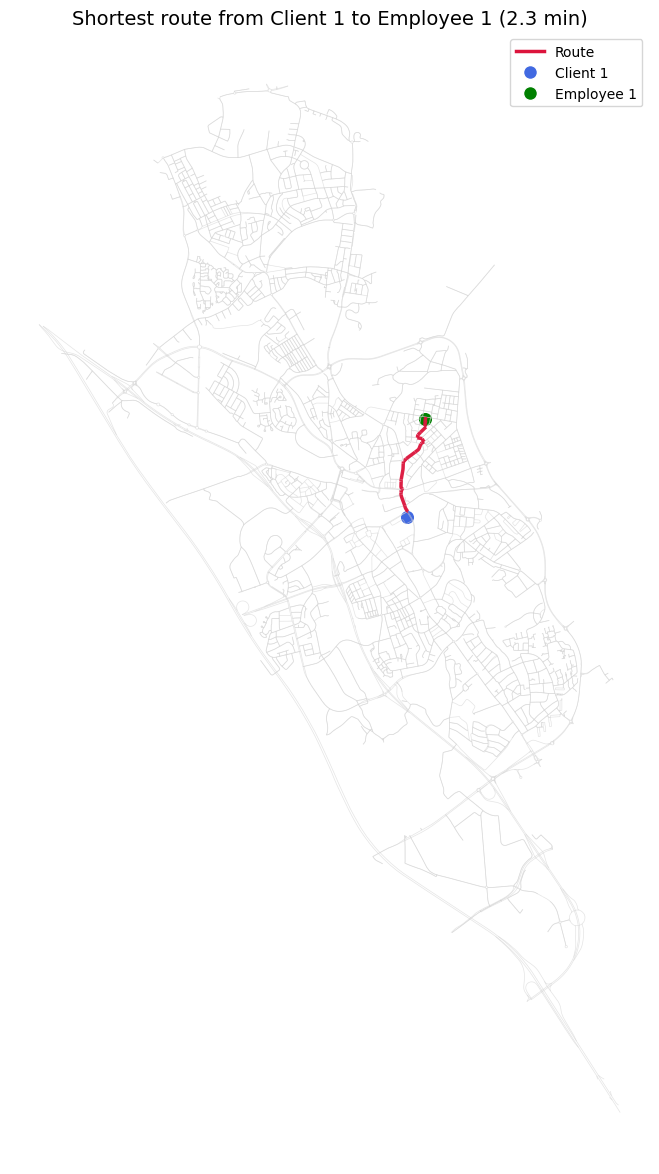

In [28]:
# Example usage and plot.
def _row_point(frame, row_index):
    row = frame.iloc[row_index]
    if "geometry" in frame.columns and row.get("geometry") is not None:
        return row["geometry"]
    if "lat" in frame.columns and "lon" in frame.columns:
        return gpd.points_from_xy([row["lon"]], [row["lat"]])[0]
    if "coordinates" in frame.columns:
        parts = str(row["coordinates"]).strip().split()
        if len(parts) != 2:
            raise ValueError("coordinates must contain two values: latitude and longitude.")
        lat_value = float(parts[0])
        lon_value = float(parts[1])
        return gpd.points_from_xy([lon_value], [lat_value])[0]
    raise ValueError("No point location columns found for this row.")

start_node = int(clients_df.iloc[0]["u"])
end_node = int(employees_df.iloc[0]["u"])
route_info = get_route_between_nodes(
    road_graph,
    start_node,
    end_node,
    weight="travel_time_min",
)

print(route_info["path_nodes"])
print(route_info["route_value"])

route_gdf = gpd.GeoDataFrame(
    geometry=route_info["route_geometries"],
    crs="EPSG:4326",
).to_crs(epsg=3857)
edges_plot = edges_gdf.to_crs(epsg=3857)

start_point = gpd.GeoSeries([_row_point(clients_df, 0)], crs="EPSG:4326").to_crs(epsg=3857)
end_point = gpd.GeoSeries([_row_point(employees_df, 0)], crs="EPSG:4326").to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12))
edges_plot.plot(ax=ax, color="lightgray", linewidth=0.5, alpha=0.6)
route_gdf.plot(ax=ax, color="crimson", linewidth=2.5, alpha=0.95)
start_point.plot(ax=ax, color="royalblue", markersize=70, alpha=1.0)
end_point.plot(ax=ax, color="green", markersize=70, alpha=1.0)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color="crimson", lw=2.5, label="Route"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="royalblue", markersize=10, label="Client 1"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="green", markersize=10, label="Employee 1"),
]
ax.legend(handles=legend_handles, loc="best")

ax.set_title(
    f"Shortest route from Client 1 to Employee 1 ({route_info['route_value']:.1f} min)",
    fontsize=14,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()